In [1]:
import os 
import sys
import multiprocessing
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.datasets import Mante, Mante_Teacher
from vi_rnn.saving import save_model, load_model

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params


torch.manual_seed(0)
np.random.seed(0)

%matplotlib inline

In [2]:
figures_dir = '../../figures'
cuda = False  # toggle if GPU is available
device = 'cpu'
neuromodulation_mechanisms = ['additive', 'rank', 'presynaptic', 'postsynaptic'] # one of 'rank', 'presynaptic', 'postsynaptic', 'additive'
train_nm_params = True
train_batches = 4

In [3]:
train_teacher = False
rank = 1

data_dir = {}
teachers = {}
teacher_model_params = {} 
teacher_task_params = {} 
teacher_training_params = {} 
teacher_tasks = {}

for i, mech in enumerate(neuromodulation_mechanisms):
    data_dir[mech] = f"../../data/mante_{mech}_rank_{rank}/"
    if train_teacher:
        mante = Mante()
        model_params, training_params = get_default_params(n_rec=60)
        training_params["n_epochs"] = 1000
        training_params["l2_rates_reg"] = 0.1
        model_params['rank'] = rank
        model_params['n_inp'] = 2
        training_params["neuromodulation"] = mech
        model_params['neuromodulation'] = mech
        model_params['ds'] = 2
        rnn_mante = RNN(model_params)
        losses, reg_losses = train_rnn(
            rnn_mante, training_params, mante, sync_wandb=False
        )

        save_rnn(
            data_dir[mech] + f"rnn_mante_{mech}_rank_{model_params['rank']}_final",
            rnn_mante,
            model_params,
            {},
            training_params,
        )

        teachers[mech] = rnn_mante
        teacher_model_params[mech] = model_params 
        teacher_task_params[mech] = {}
        teacher_training_params[mech] = training_params
    else:
        teachers[mech], teacher_model_params[mech], teacher_task_params[mech], teacher_training_params[mech] = load_rnn(
            data_dir[mech] + f"rnn_mante_{mech}_rank_{rank}_final"
        )
    batch_size = 4
    task_params = {
        "name": "mante",
        "n_neurons": teachers[mech].rnn.N,
        "out": "currents",
        "r0": 0,
        "R_x": 0.1,
        "R_z": 0.05,
        "n_trials": 400,
        "du": 2,
        "dz": 1,
        "neuromodulation": mech
    }
    rnn = teachers[mech]
    U, V, B = extract_orth_basis_rnn(rnn)
    I = rnn.rnn.w_inp.detach()
    A = rnn.rnn.A.detach() 

    with torch.no_grad():
        teacher_tasks[mech] = Mante_Teacher(task_params, 
                                            teacher_task_params[mech], 
                                            U, V, B, I, A, 
                                            decay=0.9
                                            )

model_dir = "../../models/students/"

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\py_rnn\train.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torc

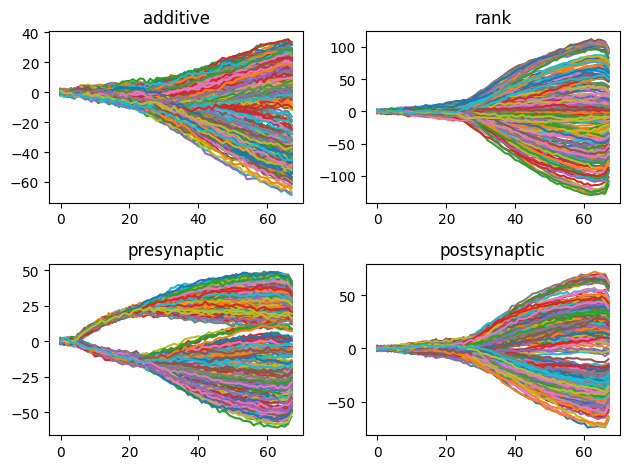

In [4]:
fig, ax = plt.subplots(2, 2)
i, j = 0, 0
for idx, mech in enumerate(neuromodulation_mechanisms):
    z = teacher_tasks[mech].data @ teachers[mech].rnn.m 
    for b in range(z.shape[0]):
        trial_latent = z[b].detach()
        if trial_latent.min() < -300: continue
        ax[i, j].plot(np.arange(0, len(trial_latent)), trial_latent)
        ax[i, j].set_title(mech)
    j += 1
    if j > 1: i, j = i + 1, 0
plt.tight_layout()

In [5]:
student_models = {}
for tch_mech in neuromodulation_mechanisms:
    for std_mch in neuromodulation_mechanisms:
        student_models[f"{tch_mech}_{std_mch}"] = []
        for i in range(5, 11):
            filename = f'../../models/students/mante_{tch_mech}_{std_mch}_{i}'
            model, vae_params, task_params, training_params = load_model(name=filename)
            student_models[f"{tch_mech}_{std_mch}"].append(model)

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_par

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'c

In [6]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from evaluation.kl_Gauss import calc_kl_from_data

num_experiments = 5
predictions = torch.zeros((len(neuromodulation_mechanisms), 
                           len(neuromodulation_mechanisms),
                           num_experiments,
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[0],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[1],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[2]
                           ))

experiments = [0, 1, 2, 3, 5]

for i, tm in enumerate(neuromodulation_mechanisms):
    for j, sm in enumerate(neuromodulation_mechanisms):
        # if i != j: continue 
        for k, l in enumerate(experiments):
            student = student_models[f"{tm}_{sm}"][l]
            X_pred = torch.zeros_like(teacher_tasks[tm].data) 
            student.eval()      
            for b in range(teacher_tasks[tm].data.shape[0]):
                X_pred[b] = predict_X(
                    student,
                    teacher_tasks[tm].data.size(1),
                    teacher_tasks[tm].data[b].T,
                    teacher_tasks[tm].stim[b].T.unsqueeze(0),
                    teacher_tasks[tm].s[b].T.unsqueeze(0),
                ).reshape(teacher_model_params[tm]["n_rec"], -1).T

            predictions[i, j, k] = X_pred

In [7]:
num_neurons = 60
num_experiments = 5 

r2_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), num_experiments, num_neurons)
pr_scores = torch.zeros_like(r2_scores)
kl_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), num_experiments, 1)

for i, tch in enumerate(neuromodulation_mechanisms):
    targ = teacher_tasks[tch].data.reshape(-1, num_neurons)
    for j, std in enumerate(neuromodulation_mechanisms):
        for k in range(num_experiments):
            pred = predictions[i, j, k].reshape(-1, num_neurons)
            r2_scores[i, j, k] = torch.tensor([r2_score(targ[:, i], pred[:, i]) for i in range(num_neurons)])
            pr_scores[i, j, k] = torch.tensor([pearsonr(targ[:, i], pred[:, i])[0] for i in range(num_neurons)])
            kl_scores[i, j, k] = torch.tensor([calc_kl_from_data(pred, targ)])


n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outlie

In [8]:
import numpy as np

def numpy_to_latex(array, column_names=None, caption="My Table", label="tab:my_table", tight=False, kl=False):
    """
    Converts a NumPy array to a LaTeX table with optional column names and bold first column.
    
    Parameters:
        array (numpy.ndarray): The NumPy array to convert.
        column_names (list): Optional list of column names.
        caption (str): Caption for the LaTeX table.
        label (str): Label for referencing the table.
    
    Returns:
        str: The LaTeX code for the table.
    """
    if array.ndim != 2:
        raise ValueError("Only 2D arrays are supported.")
    
    rows, cols = array.shape
    
    # if column_names and len(column_names) != cols:
    #     raise ValueError("Number of column names must match the number of columns in the array.")
    
    # Start table
    latex_table = "\\begin{table}[h!]\n"
    latex_table += "\\centering\n"
    if tight: 
        latex_table += "\\setlength{\\tabcolsep}{4pt} \\\\n"
        latex_table += "\\small \\\\n"
    latex_table += "\\begin{tabular}{" + "l " + "c " * (cols) + "}\n"  # Left align for first column
    latex_table += "\\hline\n"
    
    # Add column names if provided
    if column_names:
        column_names_bold = ["\\textbf{" + col.replace('_', '\\_') + "}" for col in column_names]
        latex_table += " & "
        latex_table += " & ".join(column_names_bold) + " \\\\\n"
        latex_table += "\\hline\n"
    
    # Add rows
    if kl == False:
        max_idx = np.argmax(array, axis=1)
    else: 
        max_idx = np.argmin(array, axis=1)
    for i, row in enumerate(array):
        row_str_lst = list(map(str, row))
        for j in range(len(row_str_lst)):
            if j == max_idx[i]:
                row_str_lst[j] = "\\textbf{" + row_str_lst[j] + "}"
        row_bold_first_col = ["\\textbf{" + str(column_names[i]) + "}"] + row_str_lst
        latex_table += " & ".join(row_bold_first_col) + " \\\\\n"
    
    # Add table end
    latex_table += "\\hline\n"
    latex_table += "\\end{tabular}\n"
    
    # Add caption and label
    latex_table += "\\caption{" + caption.replace('_', '\\_') + "}\n"
    # latex_table += "\\label{" + label.replace('_', '\\_') + "}\n"
    latex_table += "\\end{table}"
    
    return latex_table

In [9]:
r2_scores = r2_scores.permute(0, 1, 3, 2)
pr_scores = pr_scores.permute(0, 1, 3, 2)

plt.rcParams.update({
    "font.family": "DejaVu Sans",  # Replace with your desired font name
    "font.size": 8               # Adjust the font size
})

In [10]:
def plot_histogram(tch_idx, scores, fig_title):
    for i in range(len(neuromodulation_mechanisms)):
        plt.hist(scores[tch_idx, i], alpha=0.5, bins=np.linspace(-1, 1, 20), label=neuromodulation_mechanisms[i])
    plt.title(fig_title)
    plt.legend()

def plot_bar(scores, tch_idx, fig_title):
    plt.bar(['additive', 'rank', 'presynaptic', 'postsynaptic'], scores[tch_idx].flatten())
    plt.title(fig_title)

In [11]:
r2_medians = np.median(r2_scores, axis=2)
pr_medians = np.median(pr_scores, axis=2)



In [12]:
r2_median_means = r2_medians.mean(axis=2)
pr_median_means = pr_medians.mean(axis=2)
kl_means = kl_scores.mean(axis=2)

Text(0.5, 1.0, '$R^2$')

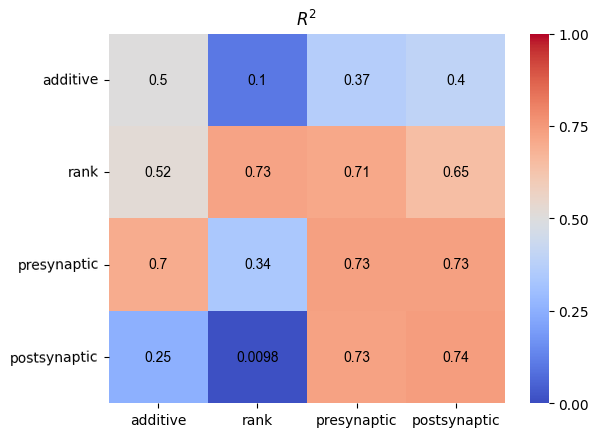

In [61]:
import seaborn as sns 
sns.heatmap(r2_median_means, annot=True, cmap="coolwarm", annot_kws={"fontname": "Arial", "fontsize": 10, "color": "black"}, vmin=0.0, vmax=1.0, cbar_kws={'ticks': [0, 0.25, 0.5, 0.75, 1.0]}, xticklabels=neuromodulation_mechanisms, yticklabels=neuromodulation_mechanisms)
plt.xticks(rotation=0)
plt.yticks(rotation=1)
plt.rcParams.update({
    "font.family": "DejaVu Sans",  # Replace with your desired font name
    "font.size": 10             # Adjust the font size
})
plt.title(f"$R^2$")
# plt.savefig("mean_r2.svg", format="svg", bbox_inches='tight')

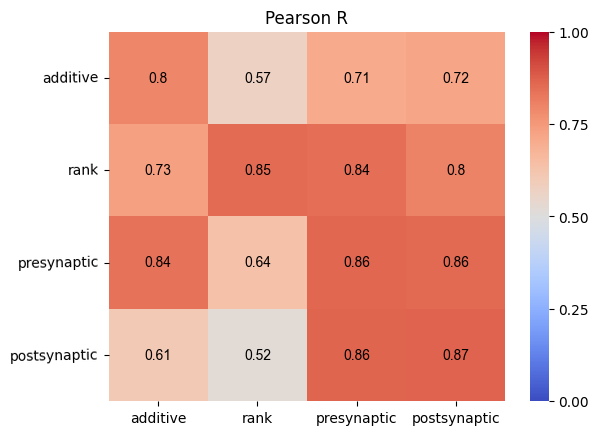

In [62]:
sns.heatmap(pr_median_means, annot=True, cmap="coolwarm",annot_kws={"fontname": "Arial", "fontsize": 10, "color": "black"}, vmin=0.0, vmax=1.0, cbar_kws={'ticks': [0, 0.25, 0.5, 0.75, 1.0]}, xticklabels=neuromodulation_mechanisms, yticklabels=neuromodulation_mechanisms)
plt.title(f"Pearson R")
plt.xticks(rotation=0)
plt.yticks(rotation=1)
plt.rcParams.update({
    "font.family": "DejaVu Sans",  # Replace with your desired font name
    "font.size": 10             # Adjust the font size
})
plt.savefig("mean_r.svg", format="svg", bbox_inches='tight')

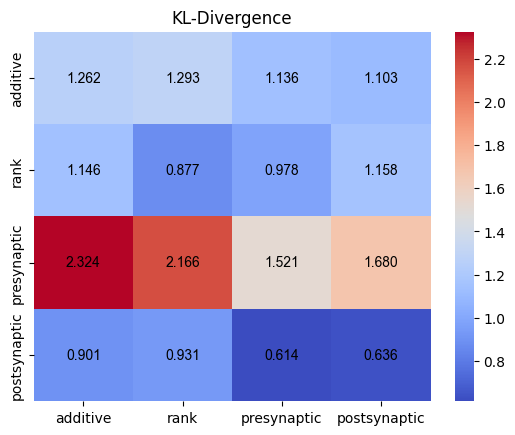

In [63]:
sns.heatmap(kl_means.reshape(4, 4), annot=True, fmt=".3f", annot_kws={"fontname": "Arial", "fontsize": 10, "color": "black"}, cmap="coolwarm", xticklabels=neuromodulation_mechanisms, yticklabels=neuromodulation_mechanisms)
plt.title(f"KL-Divergence")
plt.savefig("mean_kl.svg", format='svg', bbox_inches='tight')

In [141]:
latex_code = numpy_to_latex(r2_medians[:, :, 0], column_names=neuromodulation_mechanisms, caption="Experiment 1, Median $R^2$ of neurons in student models. Rows are teachers, columns are students", label="tab:example_table")
print(latex_code)

\begin{table}[h!]
\centering
\begin{tabular}{l c c c c }
\hline
 & \textbf{additive} & \textbf{rank} & \textbf{presynaptic} & \textbf{postsynaptic} \\
\hline
\textbf{additive} & \textbf{0.55113244} & 0.15234995 & 0.43566155 & 0.46121895 \\
\textbf{rank} & 0.4824882 & \textbf{0.85395724} & 0.83373433 & 0.720034 \\
\textbf{presynaptic} & 0.7749547 & 0.34747967 & 0.7430917 & \textbf{0.82636607} \\
\textbf{postsynaptic} & 0.34466803 & -0.106644094 & \textbf{0.82961893} & 0.8049631 \\
\hline
\end{tabular}
\caption{Experiment 1, Median $R^2$ of neurons in student models. Rows are teachers, columns are students}
\end{table}


In [ ]:
def plot_histogram(tch_idx, scores, fig_title):
    for i in range(len(neuromodulation_mechanisms)):
        plt.hist(scores[tch_idx, i], alpha=0.5, bins=np.linspace(-1, 1, 20), label=neuromodulation_mechanisms[i])
    plt.title(fig_title)
    plt.legend()

In [21]:
r2_scores_agg = np.transpose(r2_scores, (1, 0, 2, 3)).reshape(4, -1)
bins = np.linspace(-1, 1, 21)
hist_agg_add, _ = np.histogram(r2_scores_agg[0], bins=bins)
hist_agg_rank, _ = np.histogram(r2_scores_agg[1], bins=bins)
hist_add_add, _ = np.histogram(r2_scores[0, 0].reshape(1, -1), bins=bins)
hist_rank_rank, _ = np.histogram(r2_scores[1, 1].reshape(1, -1), bins=bins) 

hist_agg_add -= hist_add_add
hist_agg_rank -= hist_rank_rank

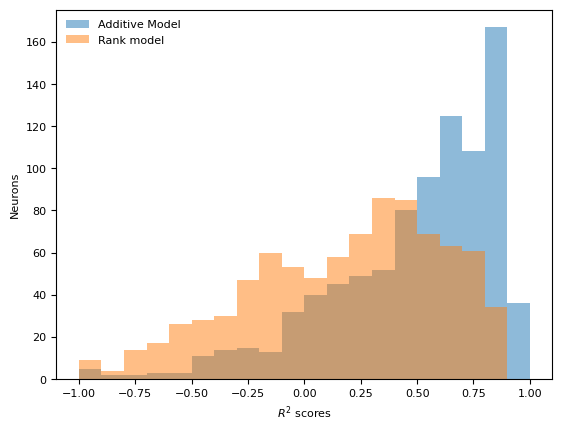

In [41]:
bin_centers = (bins[:-1] + bins[1:])/2
plt.bar(bin_centers, hist_agg_add, alpha=0.5, width=(bins[1] - bins[0]), label="Additive Model")
plt.bar(bin_centers, hist_agg_rank, alpha=0.5, width=(bins[1] - bins[0]), label="Rank model")

# plt.title(fig_title)
plt.xlabel(f"$R^2$ scores")
plt.ylabel(f"Neurons")
legend = plt.legend(frameon=False)
# Add text just below the legend
plt.savefig("additive_vs_rank.svg", format='svg', bbox_inches='tight')

In [26]:
from scipy.stats import ttest_rel
ttest_rel(r2_scores_agg[0, :], r2_scores_agg[1, :])

TtestResult(statistic=18.955815777664856, pvalue=2.7150413709724507e-70, df=1199)

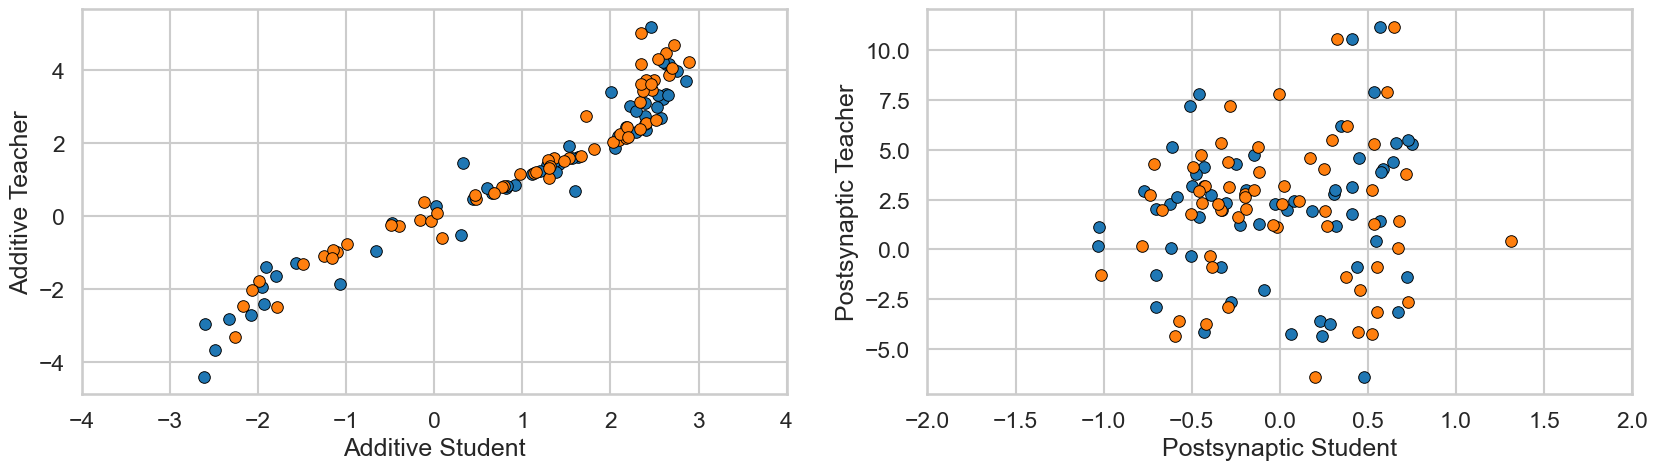

In [71]:
import pandas as pd 

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=False)
sns.set_style("whitegrid")
sns.set_context("talk") 

data = pd.DataFrame({
    'teacher0': teachers["additive"].rnn.A[:, 0].detach(),
    'teacher1': teachers["additive"].rnn.A[:, 1].detach(),
    'teacher2': teachers["postsynaptic"].rnn.A[:, 0].detach(),
    'teacher3': teachers["postsynaptic"].rnn.A[:, 0].detach(),
    'additive0': student_models["additive_additive"][0].rnn.transition.A[:, 0].detach(),
    'additive1': student_models["additive_additive"][0].rnn.transition.A[:, 1].detach(),
    'postsynaptic0': student_models["postsynaptic_postsynaptic"][0].rnn.transition.A[:, 0].detach(),
    'postsynaptic1': student_models["postsynaptic_postsynaptic"][0].rnn.transition.A[:, 1].detach(),

})

# plt.rcParams.update(plt.rcParamsDefault)

sns.scatterplot(ax=axes[0], x='additive0', y='teacher0', data=data, color='#1f77b4', edgecolor='k', s=70)
sns.scatterplot(ax=axes[0], x='additive1', y='teacher1', data=data, color='#ff7f0e', edgecolor='k', s=70)

sns.scatterplot(ax=axes[1], x='postsynaptic0', y='teacher2', data=data, color='#1f77b4', edgecolor='k', s=70)
sns.scatterplot(ax=axes[1], x='postsynaptic1', y='teacher3', data=data, color='#ff7f0e', edgecolor='k', s=70)

axes[0].set_ylabel('Additive Teacher')
axes[0].set_xlabel('Additive Student')
# axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlim(-4, 4)

axes[1].set_xlabel('Postsynaptic Student')
axes[1].set_ylabel('Postsynaptic Teacher')
# axes[1].set_aspect('equal', adjustable='datalim')
# axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(-2, 2)

plt.show()
fig.savefig('nm_recovery.svg', format='svg', bbox_inches='tight')

In [70]:
def plot_raw_traces(tch, tch_idx, trial_idx, num_neurons, stud, figsize=(6, 6)):
    num_rows, num_cols = num_neurons, 5
    with plt.rc_context({'font.size': 4}):
        fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        c = ['r', 'g', 'blue', 'black', 'orange']
        column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
        neurons = np.random.choice(range(0, 60), size=num_neurons, replace=False)
        # Set titles for the top row
        for col, title in enumerate(column_titles):
            ax[0, col].set_title(title, fontsize=12)
        for i, neuron in enumerate(neurons):
            ax[i, 0].plot(tch[trial_idx, :, neuron], c=c[0])
            ymin, ymax = tch[trial_idx, :, i].min(), tch[trial_idx, :, neuron].max()
            for j in range(len(neuromodulation_mechanisms)):
                ax[i, j+1].plot(predictions[tch_idx, j, 2, trial_idx, :, neuron], label=neuromodulation_mechanisms[j], c=c[j+1])
                ymin = min(ymin, predictions[tch_idx, j, 2, trial_idx, :, neuron].min())
                ymax = max(ymax, predictions[tch_idx, j, 2, trial_idx, :, neuron].max())
                ax[i, j+1].set_yticks([])
            for j in range(0, len(neuromodulation_mechanisms) + 1):
                ax[i, j].set_ylim(ymin, ymax)
                ax[i, j].set_xticks([])
                if j == 0:
                    ax[i, j].set_yticks([round(ymin.item(), 1), round(ymax.item(), 1)])
                ax[i, j].tick_params(axis='both', labelsize=7)
        # plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    fig.savefig('traces.svg', format='svg', bbox_inches='tight')

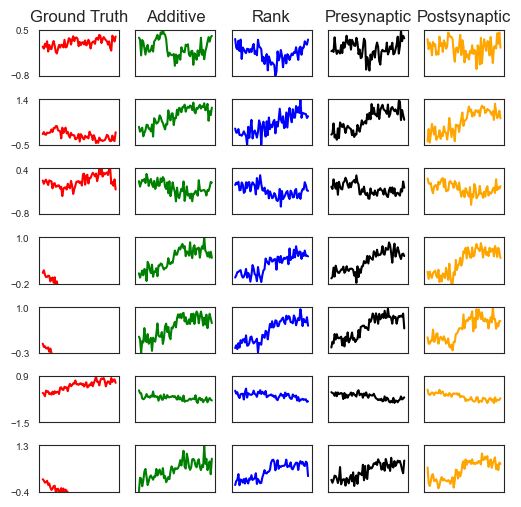

In [72]:
sns.set_style("white")
plot_raw_traces(teacher_tasks["presynaptic"].data, 3, 2, 7, predictions)

In [75]:
predictions.shape

torch.Size([4, 4, 5, 400, 68, 60])

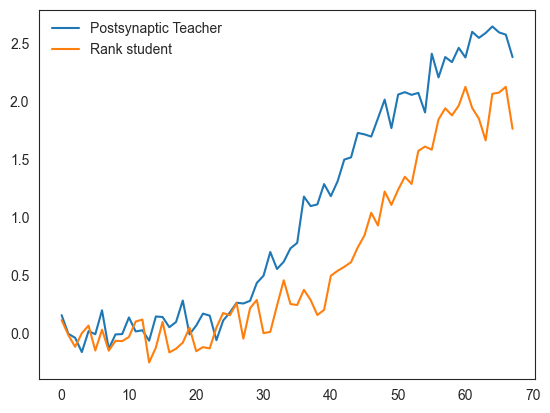

In [91]:
idx = 1
plt.plot(teacher_tasks["postsynaptic"].data[0, :, idx], label='Postsynaptic Teacher')
plt.plot(predictions[3, 0, 4, 0, :, idx], label='Rank student')
plt.legend(frameon=False)
plt.savefig('single_neuron.svg', format='svg', bbox_inches='tight')

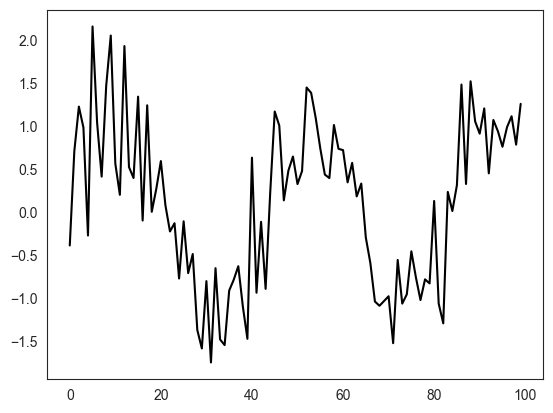

In [108]:
x = np.arange(0, 100)
y = np.sin(0.15 * x)
noise = np.random.randn(100,) * 0.5
plt.plot(y + noise, c='black')
plt.savefig('neural_activity_1.svg', format='svg', bbox_inches='tight')

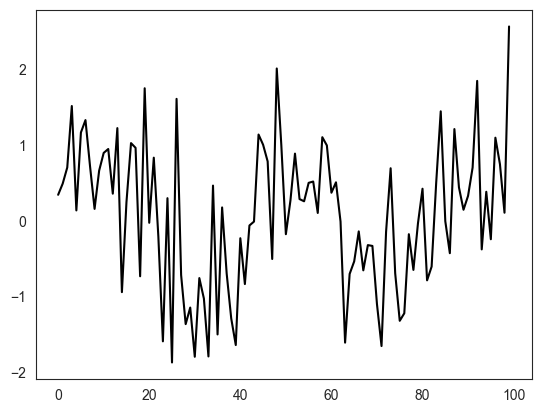

In [112]:
x = np.arange(0, 100)
y = np.sin(0.15 * x)
noise = np.random.randn(100,) * 0.7
plt.plot(y + noise, c='black')
plt.savefig('neural_activity_2.svg', format='svg', bbox_inches='tight')

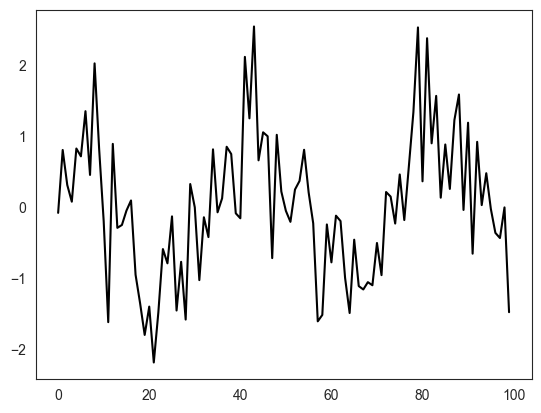

In [113]:
x = np.arange(0, 100)
y = np.cos(0.15 * x)
noise = np.random.randn(100,) * 0.7
plt.plot(y + noise, c='black')
plt.savefig('neural_activity_3.svg', format='svg', bbox_inches='tight')

In [95]:
r2 = r2_score(teacher_tasks["postsynaptic"].data[0, :, idx], predictions[3, 1, 4, 0, :, idx])
pr = pearsonr(teacher_tasks["postsynaptic"].data[0, :, idx], predictions[3, 1, 4, 0, :, idx])
pr, r2

(PearsonRResult(statistic=0.9358093545006099, pvalue=1.3535266607612191e-31),
 0.6502487372267902)

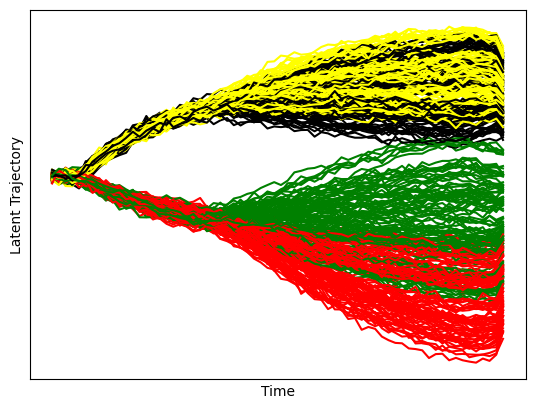

In [66]:

z_tch = teacher_tasks["presynaptic"].data @ teachers["presynaptic"].rnn.m
I = model.rnn.transition.Wu.detach().numpy()
for b in range(z_tch.shape[0]):
    trial = z_tch[b].detach().cpu().numpy()
    if teacher_tasks["presynaptic"].s[b, :, 0].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
        # plt.plot(trial[:, 0], trial[:, 1], c='r')
    elif teacher_tasks["presynaptic"].s[b, :, 0].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 0].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
        # plt.plot(trial[:, 0], trial[:, 1], c='g')
    elif teacher_tasks["presynaptic"].s[b, :, 1].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
        # plt.plot(trial[:, 0], trial[:, 1], c='black')
    elif teacher_tasks["presynaptic"].s[b, :, 1].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 1].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
        # plt.plot(trial[:, 0], trial[:, 1], c='yellow')

plt.xticks([])
plt.yticks([])
plt.xlabel('Time')
plt.ylabel('Latent Trajectory')
plt.savefig('teacher_presynaptic.svg', format='svg', bbox_inches='tight')

# plt.title('Student activity projected on student latent space')

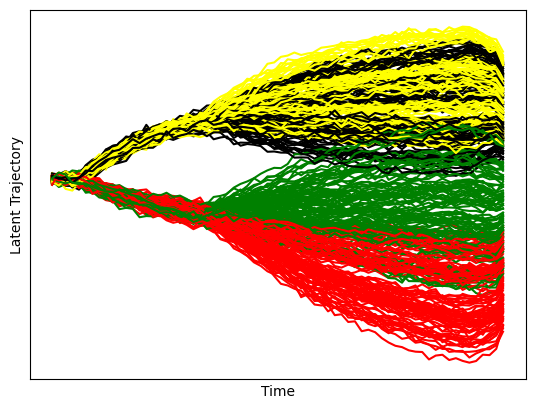

In [68]:
z_std = teacher_tasks["presynaptic"].data @ student_models["presynaptic_presynaptic"][1].rnn.transition.m
I = model.rnn.transition.Wu.detach().numpy()
for b in range(z_tch.shape[0]):
    trial = z_std[b].detach().cpu().numpy()
    if teacher_tasks["presynaptic"].s[b, :, 0].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
        # plt.plot(trial[:, 0], trial[:, 1], c='r')
    elif teacher_tasks["presynaptic"].s[b, :, 0].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 0].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
        # plt.plot(trial[:, 0], trial[:, 1], c='g')
    elif teacher_tasks["presynaptic"].s[b, :, 1].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
        # plt.plot(trial[:, 0], trial[:, 1], c='black')
    elif teacher_tasks["presynaptic"].s[b, :, 1].max() > 0 and teacher_tasks["presynaptic"].stim[b, :, 1].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
        # plt.plot(trial[:, 0], trial[:, 1], c='yellow')

plt.xticks([])
plt.yticks([])
plt.xlabel('Time')
plt.ylabel('Latent Trajectory')

plt.savefig('student_presynaptic.svg', format='svg', bbox_inches='tight')
# plt.title('Student activity projected on student latent space')

In [151]:
teacher_tasks.keys()

dict_keys(['additive', 'rank', 'presynaptic', 'postsynaptic'])